In [55]:
import torch
import argparse
import pandas as pd
import matplotlib.pyplot as plt

from models import timer_xl

from huggingface_hub import hf_hub_download

REPO_ID = "SoftwareJun/timerxl-16-100k"
FILENAME = "checkpoint.pth" 

In [ ]:
# init the args of pre-trained Timer-XL
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

args = argparse.Namespace()
args.input_token_len = 576
args.output_token_len = 24
args.d_model = 1024
args.n_heads = 8
args.e_layers = 2
args.d_ff = 2048
args.dropout = 0.1
args.activation = 'gelu'
args.use_norm = True
args.flash_attention = False
args.covariate = False
args.output_attention = False

model = timer_xl.Model(args)

checkpoint_path = hf_hub_download(
    repo_id=REPO_ID,
    filename=FILENAME
)

ckpt = torch.load(checkpoint_path, map_location="cpu")

print(ckpt.keys())  

if "model_state_dict" in ckpt:
    model.load_state_dict(ckpt["model_state_dict"])
else:
    model.load_state_dict(ckpt)

model.to(device)
model.eval()

Model(
  (embedding): Linear(in_features=576, out_features=1024, bias=True)
  (blocks): TimerBlock(
    (attn_layers): ModuleList(
      (0-1): 2 x TimerLayer(
        (attention): AttentionLayer(
          (inner_attention): TimeAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (qk_proj): QueryKeyProjection(
              (query_proj): RotaryProjection()
              (key_proj): RotaryProjection()
            )
            (attn_bias): BinaryAttentionBias(
              (emb): Embedding(2, 8)
            )
          )
          (query_projection): Linear(in_features=1024, out_features=1024, bias=True)
          (key_projection): Linear(in_features=1024, out_features=1024, bias=True)
          (value_projection): Linear(in_features=1024, out_features=1024, bias=True)
          (out_projection): Linear(in_features=1024, out_features=1024, bias=True)
        )
        (conv1): Conv1d(1024, 2048, kernel_size=(1,), stride=(1,))
        (conv2): Conv1d(2048, 1024,

In [71]:
# ── Cell 1: Imports & Config ───────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

lookback_length = 576
prediction_length = 24

# ── Cell 2: Load & Preprocess ──────────────────────────────────────────────────
df = pd.read_csv("Dataset/btc_test_1k_back_high.csv")

# Drop timestamp column if present (same logic as data_loader.py)
if isinstance(df[df.columns[0]].iloc[2], str):
    data = df[df.columns[1:]].values
else:
    data = df.values

# Scale using lookback as the fitting window (zero-shot: no separate train split)
scaler = StandardScaler()
scaler.fit(data[:lookback_length])
data_scaled = scaler.transform(data)

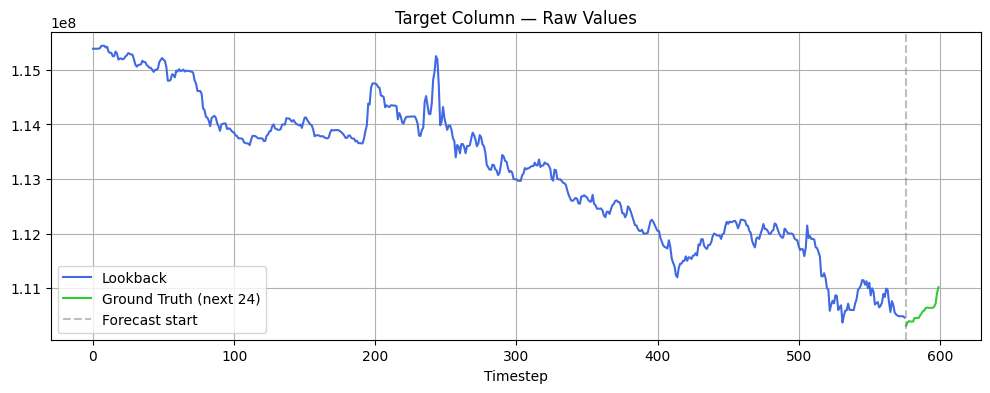

In [72]:
target_col_raw = data[:lookback_length + prediction_length, -1]  # last column, raw

plt.figure(figsize=(12, 4))
plt.plot(range(lookback_length), target_col_raw[:lookback_length],
         color="royalblue", label="Lookback")
plt.plot(range(lookback_length, lookback_length + prediction_length),
         target_col_raw[lookback_length:],
         color="limegreen", label="Ground Truth (next 24)")
plt.axvline(x=lookback_length, color="gray", linestyle="--", alpha=0.5, label="Forecast start")
plt.title("Target Column — Raw Values")
plt.xlabel("Timestep")
plt.legend()
plt.grid()
plt.show()

In [ ]:
# batch_x shape from dataloader: (B, seq_len, n_vars)
input_tensor = torch.tensor(data_scaled[:lookback_length]).unsqueeze(0).float().to(device)
# shape: (1, 576, n_vars)

x_mark = torch.zeros((1, lookback_length, 1)).to(device)
y_mark = torch.zeros((1, lookback_length, 1)).to(device)

model.eval().to(device)
with torch.no_grad():
    output = model(input_tensor, x_mark, y_mark)
    # output shape: (1, seq_len_out, n_vars)

pred_scaled = output[0, :prediction_length, -1]
pred_scaled = pred_scaled.cpu().numpy()

In [74]:
n_vars = data.shape[1]
last_col_idx = n_vars - 1

def inverse_col(scaled_vals, scaler, col_idx):
    dummy = np.zeros((len(scaled_vals), scaler.n_features_in_))
    dummy[:, col_idx] = scaled_vals.numpy() if isinstance(scaled_vals, torch.Tensor) else scaled_vals
    return scaler.inverse_transform(dummy)[:, col_idx]

pred_actual = inverse_col(pred_scaled, scaler, last_col_idx)

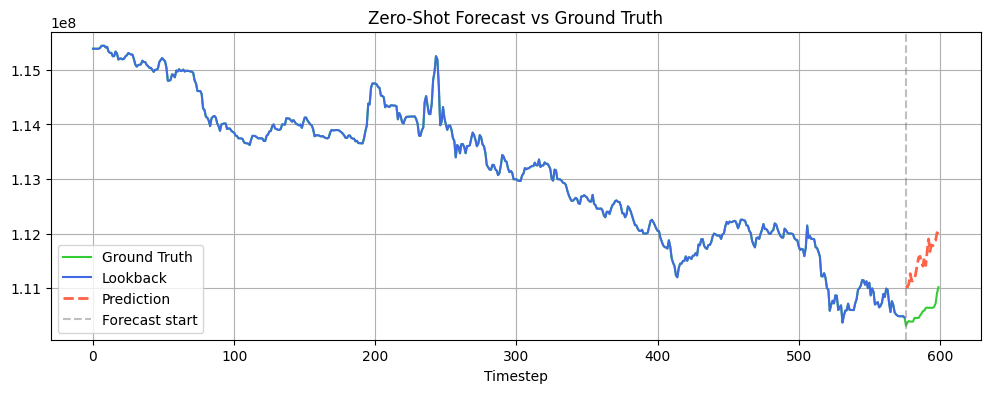

In [75]:
gt_col = data[:, -1]   # last column, raw, full length

plt.figure(figsize=(12, 4))
plt.plot(range(lookback_length + prediction_length),
         gt_col[:lookback_length + prediction_length],
         color="limegreen", label="Ground Truth")
plt.plot(range(lookback_length),
         gt_col[:lookback_length],
         color="royalblue", label="Lookback")
plt.plot(range(lookback_length, lookback_length + prediction_length),
         pred_actual,
         color="tomato", linestyle="--", linewidth=2, label="Prediction")
plt.axvline(x=lookback_length, color="gray", linestyle="--", alpha=0.5, label="Forecast start")
plt.title("Zero-Shot Forecast vs Ground Truth")
plt.xlabel("Timestep")
plt.legend()
plt.grid()
plt.show()